# **What Affects your Mental Health?**
**Spring 2026 Data Science Project**

**Group Members: Anannya Trehan, Alisha Wu, Leia Spagnola, Abjini Chattopadhyay**




## Contributions

Anannya: I worked on helping to come up with the idea, doing the exploratory data analysis (specifically interpreting the heatmap), ML model training and evaluation, writing insights and references, and formatting the final report.

Alisha: I worked on helping to brainstorm the idea and possible exploratory data analysis questions, creating EDA graphs, ML model training and evaluation, and writing insights and conclusions.

Leia: I worked on dataset selection and preprocessing, drawing conclusions from our EDA, ML model training and evaluation, doing the scaler evaluation, and adding sources for further reading to the final report.

Abjini: I worked on EDA (correlation heatmap, graphs for hypothesis testing), ML model evaluation (coefficient estimation), visualizations (predicted vs. actual and residual plots), and writing insights and conclusions.

## Introduction
Our topic is mental health. We aim to determine what lifestyle factors have the greatest positive or negative effects on the mental health of adults. Answering this question is important because our generation is plagued by a mental health crisis, and the first step in addressing it is figuring out the main causes.

## Data Curation

Here is our dataset: https://www.kaggle.com/datasets/adharshinikumar/screentime-vs-mentalwellness-survey-2025

This dataset contains the results from 400 survey participants on how different lifestyle factors (sleep, screen time usage, stress levels, productivity, etc) relates to mental wellness.




In [24]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import plotly.express as px
import kagglehub

In [25]:
# creating a dataframe from the kaggle data:
# https://www.kaggle.com/datasets/adharshinikumar/screentime-vs-mentalwellness-survey-2025
path = kagglehub.dataset_download("adharshinikumar/screentime-vs-mentalwellness-survey-2025")

df = pd.read_csv(
    path + "/ScreenTime vs MentalWellness.csv"
    )

Using Colab cache for faster access to the 'screentime-vs-mentalwellness-survey-2025' dataset.


In [26]:
# columns and descriptive statistics
df.describe()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,0.0
mean,29.77750,9.024900,2.183075,6.841825,7.013175,1.397500,8.150500,54.306500,109.810000,7.905000,20.326750,NaN
std,7.46608,2.491058,1.931321,2.220896,0.852421,0.652348,2.094844,15.020054,70.007045,4.909632,20.376793,NaN
min,16.00000,1.000000,0.110000,0.890000,4.640000,1.000000,0.000000,20.600000,0.000000,0.000000,0.000000,NaN
25%,24.00000,7.372500,0.695000,5.460000,6.397500,1.000000,6.900000,43.600000,58.000000,4.575000,3.675000,NaN
50%,30.00000,9.090000,1.455000,6.700000,7.030000,1.000000,8.800000,51.750000,103.000000,7.750000,14.800000,NaN
75%,35.00000,10.495000,3.012500,8.417500,7.640000,2.000000,10.000000,63.000000,157.000000,11.025000,30.650000,NaN
max,60.00000,19.170000,12.040000,13.350000,9.740000,4.000000,10.000000,100.000000,372.000000,23.900000,97.000000,NaN


In [27]:
# drop unnamed column caused by reading csv
df.drop("Unnamed: 15", axis=1, inplace=True)

In [28]:
# examples of data for each survey respondent
df.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0


In [29]:
df.dtypes
# numerical and string columns have accurate types,
# so no casting is necessary

,0
user_id,object
age,int64
gender,object
occupation,object
work_mode,object
screen_time_hours,float64
work_screen_hours,float64
leisure_screen_hours,float64
sleep_hours,float64
sleep_quality_1_5,int64


In [30]:
df.isna().sum()
# no columns have missing data

,0
user_id,0
age,0
gender,0
occupation,0
work_mode,0
screen_time_hours,0
work_screen_hours,0
leisure_screen_hours,0
sleep_hours,0
sleep_quality_1_5,0


We did not have to do much cleaning of the dataset. All data types were correct and there were no missing values. We did have to drop the last column, as there is a [known issue](https://stackoverflow.com/questions/36519086/how-to-get-rid-of-unnamed-0-column-in-a-pandas-dataframe-read-in-from-csv-fil) that can occur when parsing CSVs where an "Unnamed" column is added to the data. The simplest solution that caused no other unwanted effects on the DataFrame index was dropping this column after parsing.

## Exploratory Data Analysis

## Conclusion 1: Finding Correlations
We aim to find correlations between mental health score and other lifestyle variables in our dataset. We will do this buy plotting a correlation heatmap between all the variables.

Text(50.5815972222222, 0.5, 'Variables')

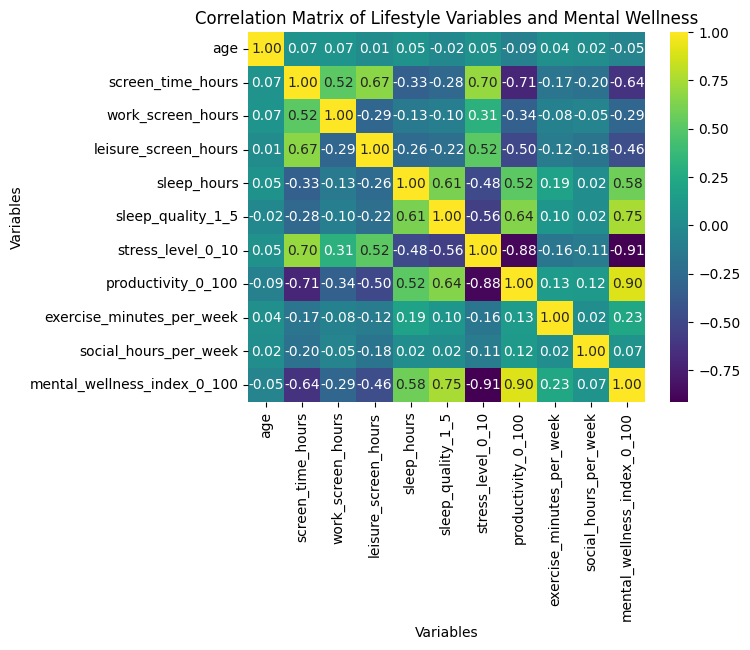

In [31]:
correlation_matrix = df[['age', 'screen_time_hours',
                         'work_screen_hours', 'leisure_screen_hours',
                         'sleep_hours', 'sleep_quality_1_5',
                         'stress_level_0_10', 'productivity_0_100',
                         'exercise_minutes_per_week',
                         'social_hours_per_week',
                         'mental_wellness_index_0_100']].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="viridis")
plt.title('Correlation Matrix of Lifestyle Variables and Mental Wellness')
plt.xlabel('Variables')
plt.ylabel('Variables')

**Conclusions:**

There are some notable correlations between mental wellness index and lifestyle variables. In particular, we select the following three to further analyze in future parts of our project:
- stress level (correlation -0.91: strong negative)
- sleep quality (correlation 0.75: strong positive)
- screen time hours (correlation -0.64: moderate negative)

## Conclusion 2: Identifying Outliers and Shapes

We will use two types of visualizations to determine the shapes of these features' distributions. Our first choice is the boxplot. This shows the quartiles, range, and any outliers present in our data.

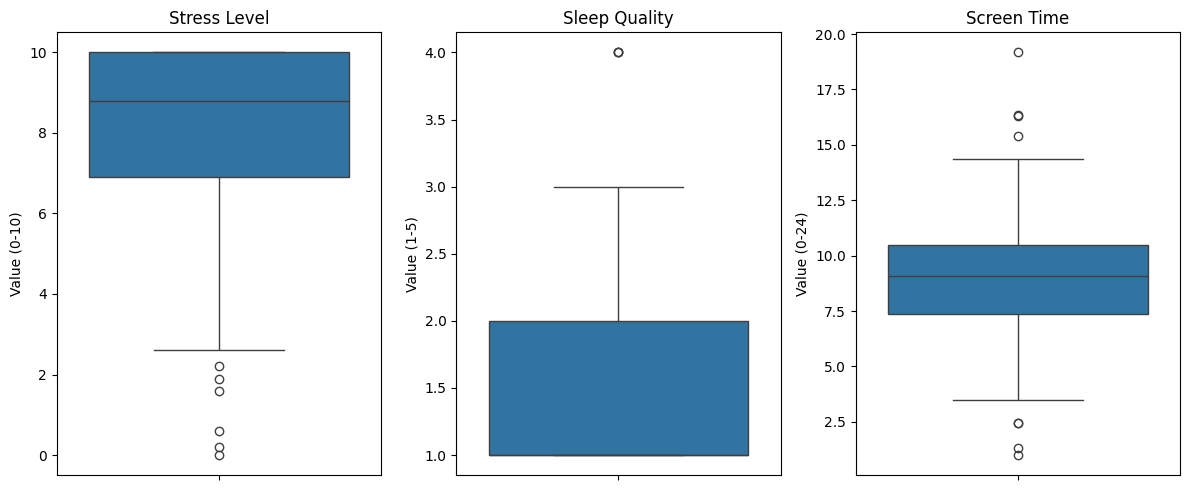

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))  # 1 row, 3 columns

sns.boxplot(y="stress_level_0_10", data=df, ax=axes[0])
axes[0].set_title("Stress Level")
axes[0].set_ylabel("Value (0-10)")

sns.boxplot(y="sleep_quality_1_5", data=df, ax=axes[1])
axes[1].set_title("Sleep Quality")
axes[1].set_ylabel("Value (1-5)")

sns.boxplot(y="screen_time_hours", data=df, ax=axes[2])
axes[2].set_title("Screen Time")
axes[2].set_ylabel("Value (0-24)")

plt.tight_layout()
plt.show()

We don't see any unreasonable outliers, but the medians for stress level and sleep quality are far from the center of the range of the data. Sleep quality appears to have a few values at 4, far from the rest of the data. We will have to take the presence of some outliers into account in the rest of our analysis.

Our next set of plots are histograms to show the shape of each feature.

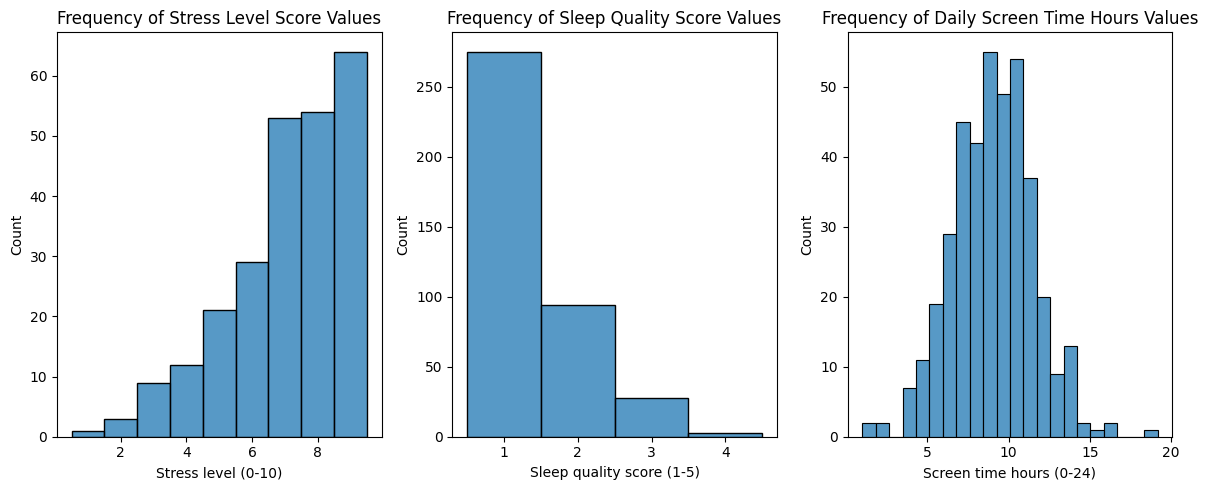

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))  # 1 row, 3 columns

sns.histplot(data=df["stress_level_0_10"], ax=axes[0],
             bins=[i + 0.5 for i in range(10)])
axes[0].set_title("Frequency of Stress Level Score Values")
axes[0].set_xlabel("Stress level (0-10)")
axes[0].set_ylabel("Count")

sns.histplot(data=df["sleep_quality_1_5"], ax=axes[1],
             bins=[i + 0.5 for i in range(5)])
axes[1].set_title("Frequency of Sleep Quality Score Values")
axes[1].set_xlabel("Sleep quality score (1-5)")
axes[1].set_ylabel("Count")

sns.histplot(data=df["screen_time_hours"], ax=axes[2])
axes[2].set_title("Frequency of Daily Screen Time Hours Values")
axes[2].set_xlabel("Screen time hours (0-24)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Conclusions:**

All values for each of these features are within reasonable ranges: 0-10, 1-5, and 0-24 respectively.
- Screen time hours appears to be distributed approximately normally.
- Stress level is left-skewed and many more samples have high stress levels, so we will have to ensure this imbalance does not negatively affect the accuracy of any machine learning models we train later.
- Sleep quality is right-skewed, so we will have to take similar considerations into account for this feature as well.

For further reading on types of skewness and other skewness tests, see https://www.geeksforgeeks.org/data-science/skewness-measures-and-interpretation/.

## Conclusion 3: Hypothesis Testing

We ask: do people with higher stress levels have significantly different mental health outcomes compared to those with lower stress levels? We will consider people with stress levels lower than or equal to 5 to be in the low stress group, and all others to be in the high stress group.

$H_0$: There is no significant difference between the mental wellness scores of people in the low stress and high stress groups.

$H_\alpha$: There is a significant difference between the mental wellness scores of people in the low stress and high stress groups.

Before choosing a statistical test, we will determine whether the distribution of mental wellness scores is normal for each group.

In [34]:
threshold = 5

higher_stress_group = df[
    df["stress_level_0_10"] > threshold][
        "mental_wellness_index_0_100"]
lower_stress_group = df[
    df["stress_level_0_10"] <= threshold][
        "mental_wellness_index_0_100"]

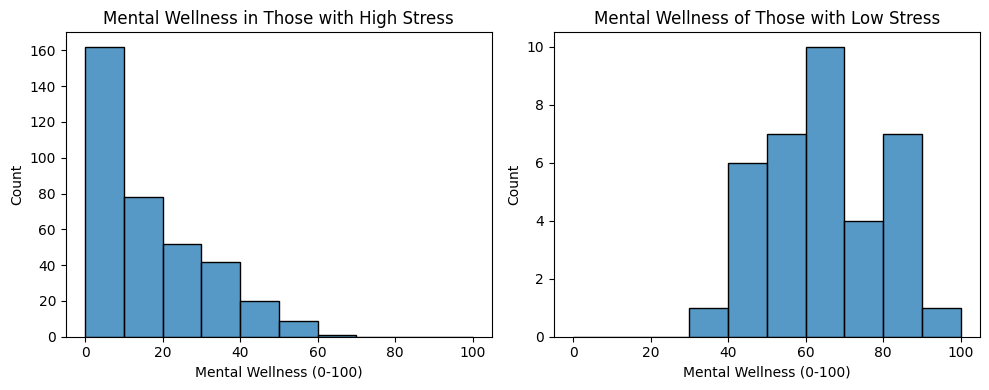

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

sns.histplot(data=higher_stress_group, ax=axes[0],
             bins=range(0, 101, 10))
axes[0].set_title("Mental Wellness in Those with High Stress")
axes[0].set_xlabel("Mental Wellness (0-100)")
axes[0].set_ylabel("Count")

sns.histplot(data=lower_stress_group, ax=axes[1],
             bins=range(0, 101, 10))
axes[1].set_title("Mental Wellness of Those with Low Stress")
axes[1].set_xlabel("Mental Wellness (0-100)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

The distribution of mental wellness index values in the high stress group appears to be right-skewed. Because of this, and the fact that we are comparing two non-paired samples, we will use the non-parametric [Mann-Whitney U](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html) test. In-depth information on this test is available [here](https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test), but [this article](https://www.statology.org/mann-whitney-u-test/) is also good for a quick tutorial.

In [36]:
alpha = 0.05
_, p_val = stats.mannwhitneyu(higher_stress_group,
                                lower_stress_group)
print(f"p-value:{p_val}")

if(p_val < alpha):
  print("We can reject the null hypothesis")
else:
  print("We fail to reject the null hypothesis")

p-value:5.165792128754523e-22
We can reject the null hypothesis


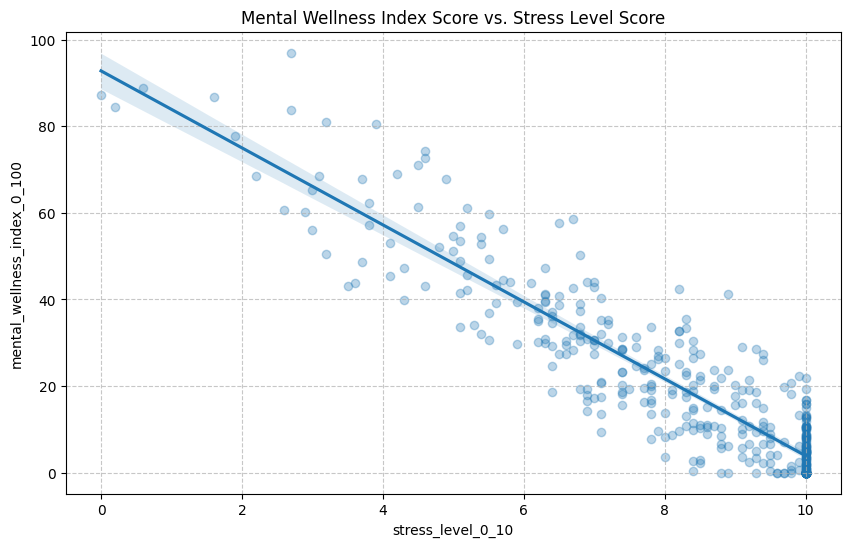

In [37]:
plt.figure(figsize=(10, 6))
sns.regplot(x='stress_level_0_10', y='mental_wellness_index_0_100',
            data=df, scatter_kws={'alpha':0.3})
plt.title("Mental Wellness Index Score vs. Stress Level Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Conclusions:**

Because the p value is lower than the significance level, we reject the null hypothesis. There is a statistically significant difference in mental health index scores between people with high stress level and people with low stress levels. Moreover from the graph, we can see that there is a negative linear relationship between stress level and mental wellness index. This supports our finding that there is a relationship between these two variables.

## Primary Analysis

We will use multiple linear regression to model mental wellness as a function of stress level, sleep quality, and screentime. This choice is in response to our finding that these three features have strong correlations with mental wellness score, and stress level in particular has a known linear relationship with mental wellness. We will use the [scikit-learn LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression) model. Interested readers can find out more about allowed model parameters in the documentation.

In [38]:
# select features we found to be most related to mental health score
X = df[["stress_level_0_10", "sleep_quality_1_5", "screen_time_hours"]]
y = df[["mental_wellness_index_0_100"]]

# split into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

We know that the stress level and sleep quality distributions are skewed. Because of this, we wanted to see if training on the data as-is negatively impacts the accuracy of the model, and if so, what feature transformations might help mitigate this. We considered using no transformations, [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler), [RobustScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), log transform, and [PowerTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html). See [this article](https://medium.com/data-science-explained/log-box-cox-and-yeo-johnson-transform-skewed-data-the-right-way-25148b3ab160) for more on how PowerTransformer makes data more normally distributed.

In [39]:
models = {
          "No transform": make_pipeline(LinearRegression()),
          "StandardScaler": make_pipeline(StandardScaler(), LinearRegression()),
          "RobustScaler": make_pipeline(RobustScaler(), LinearRegression()),
          "Log transform": make_pipeline(FunctionTransformer(lambda x : np.log(x + 1)), LinearRegression()),
          "PowerTransformer": make_pipeline(PowerTransformer(), LinearRegression())
         }

# pipelines fit and transform if applicable, then fit regression models
for model in models:
  models[model].fit(X_train, y_train)

We will now train linear regression models on the differently transformed training sets. These are linear functions $ℝ^3 → ℝ$ that can output a predicted mental wellness score for any point in the feature space (stress level, sleep quality, screen time). We will also evaluate these models to see which preprocessing technique was most effective and how close our best model can get to the true target values.

In [40]:
for model in models:
  y_pred = models[model].predict(X_test)
  print(model)
  # how much variance in the target is explained by the model
  print(f"R2 score: {r2_score(y_test, y_pred)}")
  # how far on average the model's predicted target is from the true target
  print(f"MSE: {mean_squared_error(y_test, y_pred)}")
  print("\n")

No transform
R2 score: 0.9192836621058049
MSE: 27.126717907816726


StandardScaler
R2 score: 0.919283662105805
MSE: 27.126717907816698


RobustScaler
R2 score: 0.919283662105805
MSE: 27.126717907816715


Log transform
R2 score: 0.8047803399840545
MSE: 65.6083859286844


PowerTransformer
R2 score: 0.8710434932492057
MSE: 43.339017505870274




Here we see something interesting: scaling the data has no effect on linear regression accuracy. This is because any linear transformations like subtraction or division on a feature can be accounted for by the weights and intercept of the model during training. (For example, where StandardScaler has divided all features by their mean, the no transform model has simply learned analogously scaled coefficients and is able to produce the same exact predictions). There are cases where scaling is useful for linear regression, but it also has consequences like reducing coefficient interpretability. A good starting point for further reading is [this article](https://www.geeksforgeeks.org/machine-learning/does-linear-regression-require-feature-scaling/).

We also see that usage of the log transform or PowerTransformer decreases model performance. The linear regression models trained on these transformed datasets explain less of the variance in the data and make predictions further from the true targets. So, we will move forward with our no transform model.

In [41]:
y_pred = models["No transform"].predict(X_test)

Now that we have selected our model, we can extract and examine the coefficients of the model learned in order to understand how much each feature influences mental wellness. Our regression model computes

$$\text{mental_wellness_index_0_100} = \beta_0 + \beta_1(\text{stress_level_0_10}) + \beta_2(\text{sleep_quality_1_5}) + \beta_3(\text{screen_time})$$

A larger absolute coefficient will indicate a stronger effect of the corresponding feature on the predicted mental wellness while the sign indicates the direction of that influence (e.g., positive higher values improve predicted mental wellness).

In [42]:
regr = models["No transform"].named_steps["linearregression"]

print("Intercept β₀:", regr.intercept_)
print("Coefficients β₁, β₂, β₃:", regr.coef_)

Intercept β₀: [63.31613238]
Coefficients β₁, β₂, β₃: [[-6.39853327 11.36960838 -0.75005519]]


The intercept 61.29 represents the baseline predicted mental wellness score when all features are zero.

Stress level has the largest magnitude coefficient and is negative, meaning it is the single strongest predictor of poor mental wellness. Sleep quality has a positive coefficient, meaning better sleep is associated with higher predicted mental wellness. Screen time has a smaller but still negative coefficient, meaning a more smaller but real negative effect after accounting for the effects of stress and sleep.

## Visualization

We can visualize the feature space with a 3D scatter plot. This shows us the distribution of all our features together and what kind of input the model received overall. We will then visualize the additional dimension of the target variable with color. To easily create this interactive visual, we will use [Plotly Express](https://plotly.com/python-api-reference/generated/plotly.express.scatter_3d).

In [43]:
def visualize_regression(X, y, subtitle):
  fig = px.scatter_3d(X,
                      x='stress_level_0_10',
                      y='sleep_quality_1_5',
                      z='screen_time_hours',
                      color=y,
                      labels={
                          "stress_level_0_10": "Stress level (0-10)",
                          "sleep_quality_1_5": "Sleep quality (1-5)",
                          "screen_time_hours": "Daily screen time hours"
                      },
                      title=f"Selected lifestyle features v. mental wellness score ({subtitle})",
                      range_color=[0, 100]
                      )
  fig.show()

In [44]:
visualize_regression(X_train, y_train["mental_wellness_index_0_100"], "Training")

We can see that the trend moves from poor (purple) to high (yellow) mental wellness as screen time decreases, sleep quality increases, and stress level decreases. This should be the pattern that our model learned from this training data.

In [45]:
visualize_regression(X_test, y_pred.flatten(), "Model predictions")

When we assign predicted colors to the test data points, we see a similar trend. This makes sense as our model has high performance based on the metrics we calculated.

Next, we more clearly visualize the quality of our model's predictions on the test set. We plot a predicted vs. actual plot to compare each test sample's true mental wellness score against what our model predicted. A perfect model would place every point along the diagonal line. We also plot a residual plot, which shows the error of each prediction
against the predicted value. Randomly scattered residuals around zero indicate the linear  model is a good fit for the data.

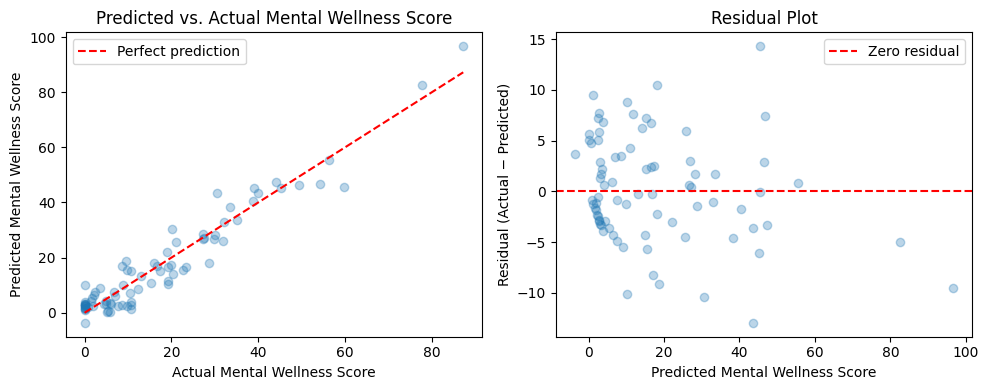

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# predicted vs actual
axes[0].scatter(y_test, y_pred, alpha = 0.3)
axes[0].plot([y_test.min().values[0], y_test.max().values[0]],
             [y_test.min().values[0], y_test.max().values[0]],
             color = "red", linestyle = "--", label = "Perfect prediction")
axes[0].set_title("Predicted vs. Actual Mental Wellness Score")
axes[0].set_xlabel("Actual Mental Wellness Score")
axes[0].set_ylabel("Predicted Mental Wellness Score")
axes[0].legend()

# residual
residuals = y_test.values.flatten() - y_pred.flatten()
axes[1].scatter(y_pred, residuals, alpha = 0.3)
axes[1].axhline(0, color = "red", linestyle = "--", label = "Zero residual")
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted Mental Wellness Score")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].legend()

plt.tight_layout()
plt.show()

The predicted vs. actual plot shows points clustering tightly around the diagonal across the full range of mental wellness scores.

The residual plot shows residuals scattered roughly around zero with no obvious curve. However, there is a very mild funnel shape. Residuals are more slightly clustered at lower predicted values and spread slightly at higher predicted values. This means the model's predictions become slightly less consistent at higher mental wellness scores, but the effect is extremely mild.

## Insights and Conclusions



Multiple linear regression performed exceptionally well, explaining approximately 92% of the variation in mental wellness scores ($R^2 ≈ 0.92$). This suggests that stress level, sleep quality, and screen time together are highly predictive of mental health in our dataset.

We selected these predictors based on our EDA where these variables showed the strong relationships with mental wellness. From our EDA, high stress and greater screen time are associated with lower mental wellness, while better sleep quality is linked to higher mental wellness.

The coefficient analysis confirmed our EDA findings, with stress level, sleep quality, and screen time having the strongest, second strongest, and weakest effects on mental wellness respectively. The ordering of these coefficient magnitudes matches the ordering of correlations we found in our EDA heatmap (stress: -0.91, sleep quality: 0.75, screen time: -0.64), which gives us confidence that the model has learned the real relationships in the data as opposed to noise.

Our decision not to apply scalers or nonlinear transformations was validated by both the metrics and the residual plot. Applying linear transformations like StandardScaler or RobustScaler has no effect on predictive accuracy because the model can compensate by learning proportionally adjusted coefficients. The log transform and PowerTransformer hurt performance because they distort the linear relationships between features and the target that the model relies on. Since our data has strong linear relationships between the features and mental wellness (as shown in the EDA and residual plot), these transformations would work against the model.

The regression visualizations of mental wellness vs. stress level showed a clear negative linear trend, and the 3D scatter plot of all three features confirmed that the feature space has a well structured linear relationship with the target.

The predicted vs. actual and residual plots confirmed that the linear model is a good fit overall with only mild heteroscedasticity at higher predicted values. This also confirms that the skewness we identified in the stress level and sleep quality distributions during EDA did not significantly hurt the model.

Our findings align with existing psychological research. Papers published in Nature and by the CDC agree that 4 or more hours of daily screentime, seperate from schoolwork, had a negative impact on children and adolescent mental health with consequences being higher risks of anxiety, depression, and behavior or conduct problems. $^{1,4}$

Papers published by NIH also emphasize that stress, both from traumatic events and everyday activities, has an adverse effect on mental health in  adults and children. $^{3}$

Lastly, there is also existing research to support the finding that sleep deprivation affects overall mental health. $^{2}$

Overall, our regression analysis suggests that stress level, sleep quality, and screen time have a statistically significant effect on mental health, which matches already existing research.

**References**

[1] Dai, Y., & Ouyang, N. (2026). Excessive screen time is associated with mental health problems in US children and adolescents: physical activity and sleep as parallel mediators. Humanities and Social Sciences Communications, -. https://doi.org/10.1057/s41599-026-06609-1

[2] Johri, K., Pillai, R., Kulkarni, A., & Balkrishnan, R. (2025). Effects of sleep deprivation on the mental health of adolescents: a systematic review. Sleep Science and Practice, 9(1). https://doi.org/10.1186/s41606-025-00127-w

[3] Schneiderman, N., Ironson, G., & Siegel, S. D. (2005). Stress and health: Psychological, behavioral, and Biological Determinants. Annual Review of Clinical Psychology, 1(1), 607–628. National Library Of Medicine. https://doi.org/10.1146/annurev.clinpsy.1.102803.144141

[4] Zablotsky, B., Ng, A. E., Black, L. I., Haile, G., Bose, J., Jones, J. R., & Blumberg, S. J. (2025). Associations Between Screen Time Use and Health Outcomes Among US Teenagers. Preventing Chronic Disease, 22. https://doi.org/10.5888/pcd22.240537